In [ ]:
from utils.models import ESMBackbone
from utils.data import ProteinDataset
import pandas as pd
from pathlib import Path
from torch.utils.data import DataLoader
import torch
from tqdm import tqdm
import numpy as np
from utils.torch import get_torch_device
import ast
import umap

In [ ]:
    
data_dir=Path('./data')
 = data_dir / "esm_features.csv"
variants = pd.read_csv(data_dir/f'{'train'}.csv')
Sequences = pd.read_csv(data_dir/'Sequences.csv', index_col='ensp')
device = get_torch_device()

In [ ]:
if not features_path.exists():
    train_dataset = ProteinDataset(split="train", variants=variants, Sequences=Sequences)
    loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
    model = ESM().to(device)
    rows = []
    for i, batch in tqdm(enumerate(loader), total=500):
        forward = model.forward(batch['input'])
        row = (batch['accession'][0], forward[0].tolist(), batch['score'][0].item())
        rows.append(row)
        if i == 500:
            break

In [ ]:

if features_path.exists():
    features_df = pd.read_csv(features_path)
    features_df['features'] = features_df['features'].apply(ast.literal_eval)
    
else:
    features_df = pd.DataFrame(rows, columns=['accession', 'features', 'score'])
    
X = np.vstack([np.array(f, dtype=np.float32) for f in features_df["features"]])



reducer = umap.UMAP(n_components=2, metric='cosine')
X_umap = np.asarray(reducer.fit_transform(X))

features_df["umap1"] = X_umap[:, 0]
features_df["umap2"] = X_umap[:, 1]

features_df.to_csv(features_path, index=False)


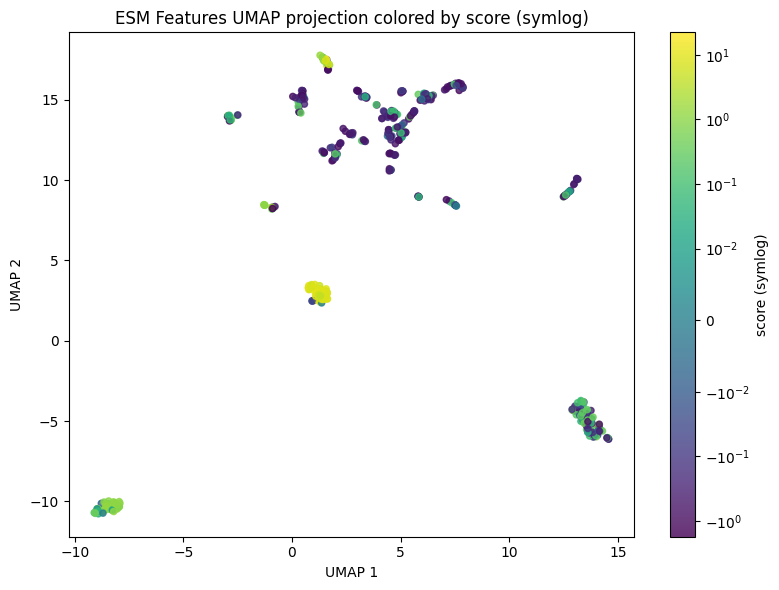

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
import numpy as np

plt.figure(figsize=(8, 6))
sc = plt.scatter(
    features_df["umap1"],
    features_df["umap2"],
    c=features_df["score"],
    cmap="viridis",
    s=20,
    alpha=0.8,
    norm=SymLogNorm(linthresh=1e-2, linscale=1.0, vmin=features_df["score"].min(), vmax=features_df["score"].max())
)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("ESM Features UMAP projection colored by score (symlog)")
plt.colorbar(sc, label="score (symlog)")
plt.tight_layout()
plt.save_fig(data_dir / "umap.png")
plt.show()
